# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import catboost as cb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import math
import holidays


# Load data

In [2]:
sales = pd.read_csv('sales.csv',parse_dates = ['Date'])
test = pd.read_csv('sample_submission.csv',parse_dates =['Date'])

In [3]:
print(f"Data train period from {sales['Date'].min().date()} to {sales['Date'].max().date()}")
print(f"Data test period from {test['Date'].min().date()} to {test['Date'].max().date()}")

Data train period from 2012-07-04 to 2022-12-31
Data test period from 2023-01-01 to 2024-07-01


In [4]:
df_sale = sales.copy()
df_sale['is_test'] = 0
df_test = test.copy()
df_test['is_test'] = 1
df = pd.concat([df_sale,df_test], ignore_index= True)

# EDA data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4381 entries, 0 to 4380
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     4381 non-null   datetime64[ns]
 1   Revenue  4381 non-null   float64       
 2   COGS     4381 non-null   float64       
 3   is_test  4381 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 137.0 KB


In [6]:
round(df.describe(),2)

,Date,Revenue,COGS,is_test
count,4381,4381.00,4381.00,4381.00
mean,2018-07-03 00:00:00,4156896.71,3581140.94,0.13
min,2012-07-04 00:00:00,279813.94,236576.31,0.00
25%,2015-07-04 00:00:00,2402388.27,2092259.75,0.00
50%,2018-07-03 00:00:00,3555473.95,3072656.32,0.00
75%,2021-07-02 00:00:00,5156699.45,4439845.57,0.00
max,2024-07-01 00:00:00,20905271.35,16535857.67,1.00
std,NaN,2541235.58,2152436.91,0.33


<Figure size 1500x1000 with 0 Axes>

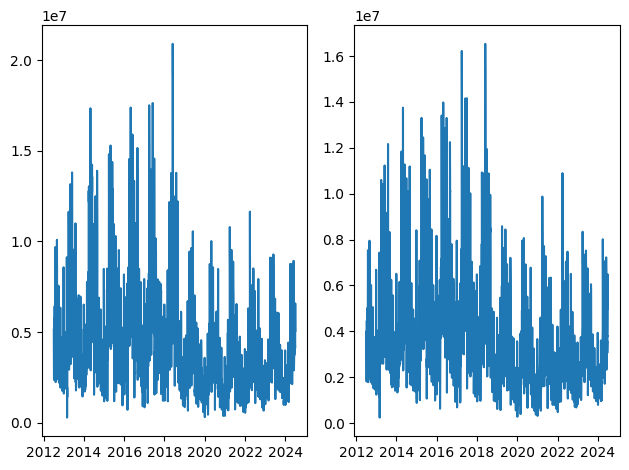

In [7]:
plt.figure(figsize= (15,10))
fig,ax = plt.subplots(nrows=1,ncols=2 )

ax[0].plot(df['Date'],df['Revenue'])
ax[1].plot(df['Date'],df['COGS'])
plt.tight_layout(
    
)

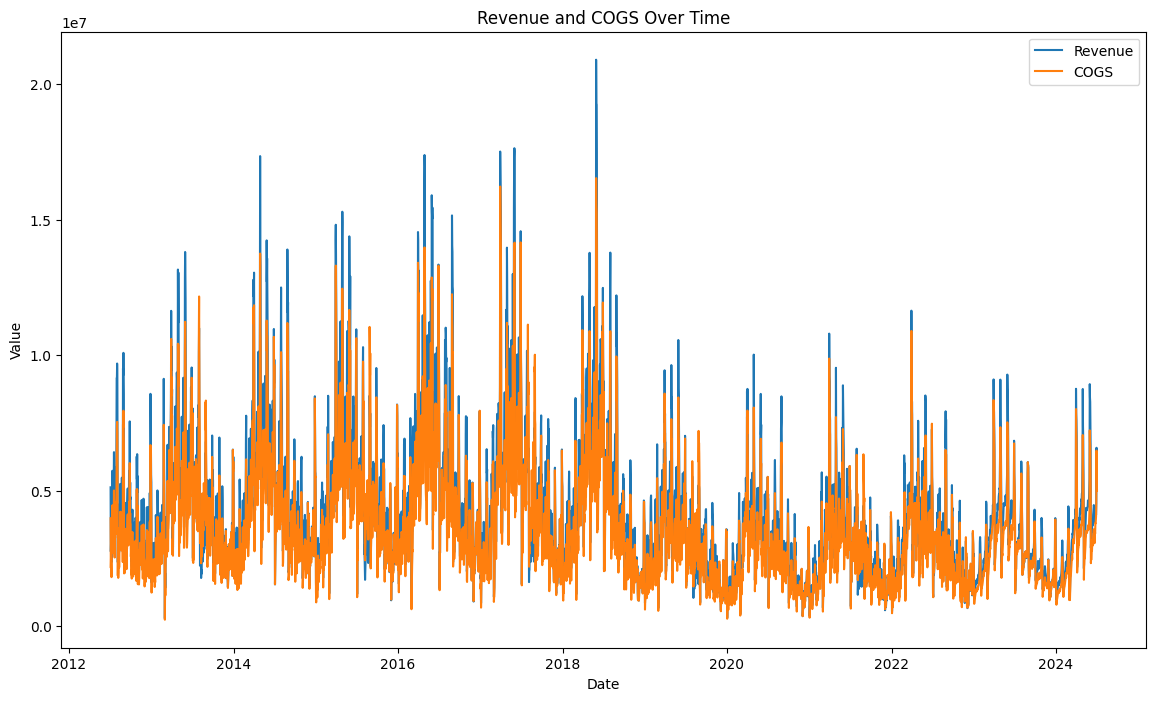

In [8]:
plt.figure(figsize=(14,8))
plt.plot(df['Date'], df['Revenue'], label='Revenue')
plt.plot(df['Date'], df['COGS'], label='COGS')
plt.title('Revenue and COGS Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

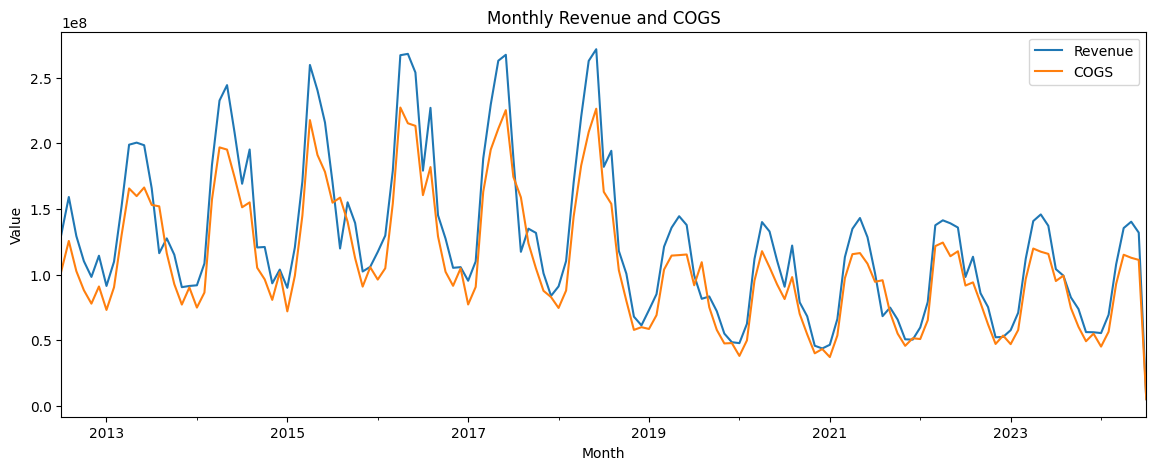

In [9]:
monthly = df.set_index('Date')[['Revenue', 'COGS']].resample('ME').sum()

monthly.plot(figsize=(14,5))
plt.title('Monthly Revenue and COGS')
plt.xlabel('Month')
plt.ylabel('Value')
plt.show()

# Feature Engineering

## Featuring time

In [10]:
# Featuring Calendar
df['days'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year
df['quarter'] = df['Date'].dt.quarter
df['day_of_week'] = df['Date'].dt.day_of_week
df['week_of_year'] = df['Date'].dt.isocalendar().week.astype('int')
df['is_weekend'] = (df['day_of_week'] >= 5).astype('int8')

# Feature special days
df['is_double_day'] = (df['days'] == df['month']).astype('int8')
## holidays in VN
vn_holidays = holidays.VN(years=range(2012, 2025))
df['is_holiday']=(df['Date'].isin(vn_holidays)).astype('int8')

# Feature cyclical
## Month cyclical
df['month_sin'] = np.sin(2* np.pi * df['month']/12)
df['month_cos'] = np.cos(2*np.pi * df['month']/12)

# Day of week cyclical
df['day_of_week_sin'] = np.sin(2* np.pi * df['day_of_week']/7)
df['day_of_week_cos'] = np.cos(2*np.pi * df['day_of_week']/7)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_27724\3873222714.py:14: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['is_holiday']=(df['Date'].isin(vn_holidays)).astype('int8')


## Featuring sales

In [11]:
# Lag feature
## sale lag
df['sale_lag_1'] = df['Revenue'].shift(1)
df['sale_lag_7'] = df['Revenue'].shift(7)
df['sale_lag_30'] = df['Revenue'].shift(30)

# Rolling feature
df['rolling_mean_7'] = df['Revenue'].rolling(7).mean()
df['rolling_mean_30'] = df['Revenue'].rolling(30).mean()
df['rolling_max_30'] = df['Revenue'].rolling(30).max()

# Training Model and Tunning Model

In [12]:
# Split to train and test set
train = df[df['is_test'] == 0].copy()
test = df[df['is_test'] == 1].copy()

X_train = train.drop(['Date','is_test','Revenue'],axis =1)
y_train = train['Revenue']
X_test = test.drop(['Date','is_test','Revenue'],axis =1)
y_test = test['Revenue']

In [13]:
models = {
    "XGBoost": xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": lgb.LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),

    "CatBoost": cb.CatBoostRegressor(
        loss_function="RMSE",
        random_state=42,
        verbose=0
    ),

    "RandomForest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )
}

In [14]:
param_grids = {
    "XGBoost": {
        "n_estimators": [500, 1000],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [3, 5, 7],
      #  "subsample": [0.8, 1.0],
      #  "colsample_bytree": [0.8, 1.0]
    },

    "LightGBM": {
        "n_estimators": [500, 1000],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [5, 10, -1],
        "num_leaves": [31, 63],
       # "subsample": [0.8, 1.0],
       # "colsample_bytree": [0.8, 1.0]
    },

    "CatBoost": {
        "iterations": [500, 1000],
        "learning_rate": [0.03, 0.05, 0.1],
       # "depth": [4, 6, 8],
        "l2_leaf_reg": [1, 3, 5]
    },

    "RandomForest": {
        "n_estimators": [500, 1000],
        "max_depth": [10, 20],
       # "min_samples_split": [2, 5],
       # "min_samples_leaf": [1, 2],
        "max_features": ["sqrt", "log2"]
    }
}

In [15]:
best_models = {}
results = []

for name, model in models.items():
    print(f"\n===== Tuning {name} =====")

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring="neg_mean_absolute_error",
        cv= 5,
        n_jobs=-1,
        verbose=2
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_models[name] = best_model

    y_pred = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "CV MAE": -grid.best_score_,
        "Test MAE": mae,
        "Test RMSE": rmse,
        "Test R2": r2
    })

results_df = pd.DataFrame(results).sort_values("Test MAE")
results_df


===== Tuning XGBoost =====
Fitting 5 folds for each of 18 candidates, totalling 90 fits

===== Tuning LightGBM =====
Fitting 5 folds for each of 36 candidates, totalling 180 fits

===== Tuning CatBoost =====
Fitting 5 folds for each of 18 candidates, totalling 90 fits

===== Tuning RandomForest =====
Fitting 5 folds for each of 8 candidates, totalling 40 fits


,Model,Best Params,CV MAE,Test MAE,Test RMSE,Test R2
2,CatBoost,"{'iterations': 1000, 'l2_leaf_reg': 1, 'learni...",214729.058241,71392.465998,99711.183224,0.996019
1,LightGBM,"{'learning_rate': 0.03, 'max_depth': 10, 'n_es...",220343.633445,77000.519350,111755.329685,0.994999
0,XGBoost,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",206770.820265,83127.017527,115219.934007,0.994684
3,RandomForest,"{'max_depth': 20, 'max_features': 'sqrt', 'n_e...",335619.383670,127502.365502,194294.526282,0.984883


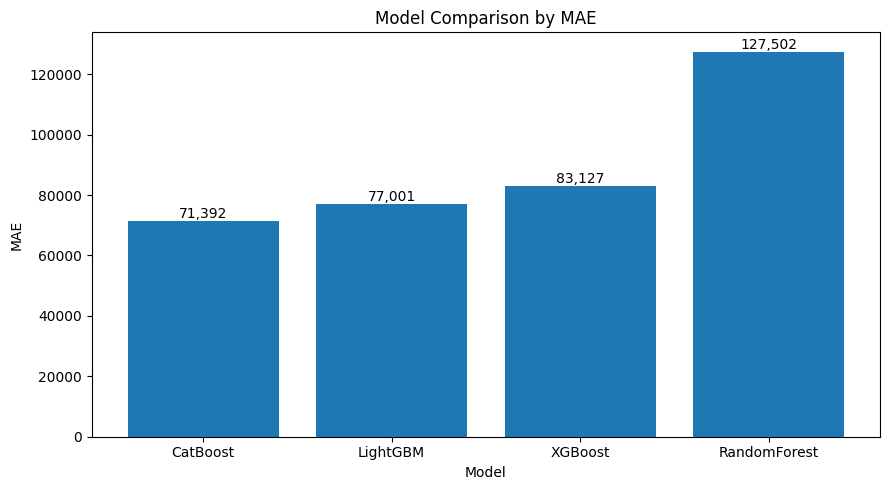

In [18]:
plt.figure(figsize=(9,5))
plt.bar(results_df["Model"], results_df["Test MAE"])
plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE")

for i, v in enumerate(results_df["Test MAE"]):
    plt.text(i, v, f"{v:,.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

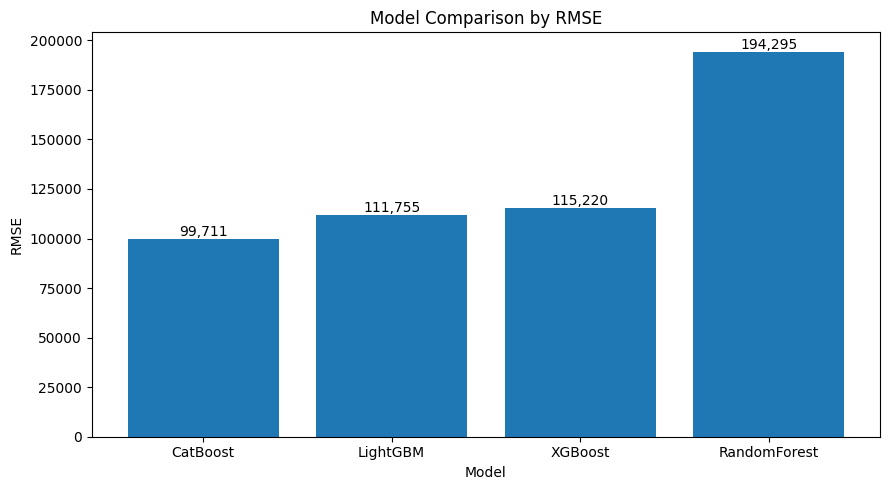

In [19]:
plt.figure(figsize=(9,5))
plt.bar(results_df["Model"], results_df["Test RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

for i, v in enumerate(results_df["Test RMSE"]):
    plt.text(i, v, f"{v:,.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

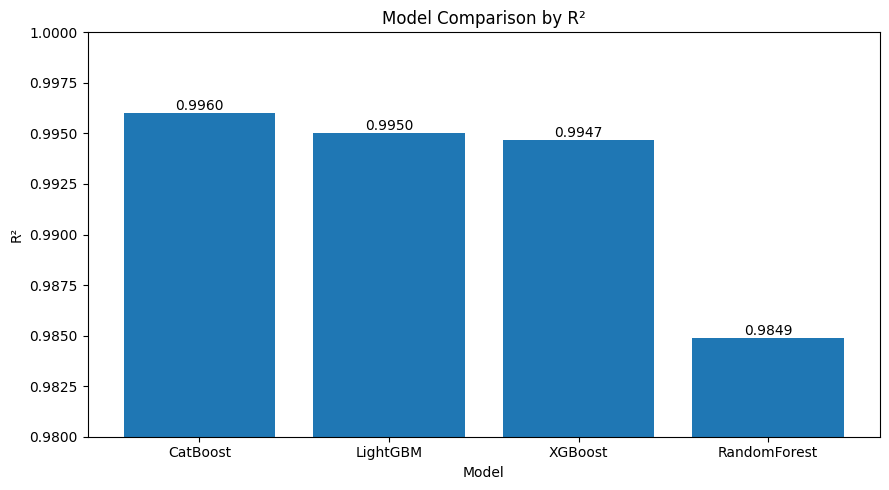

In [20]:
plt.figure(figsize=(9,5))
plt.bar(results_df["Model"], results_df["Test R2"])
plt.title("Model Comparison by R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.ylim(0.98, 1.0)

for i, v in enumerate(results_df["Test R2"]):
    plt.text(i, v, f"{v:.4f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [25]:
def get_feature_importance(model, X_train, model_name):
    if model_name == "CatBoost":
        importance = model.get_feature_importance()
    else:
        importance = model.feature_importances_
    
    fi = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": importance,
        "Model": model_name
    }).sort_values("Importance", ascending=False)
    
    return fi

In [26]:
feature_importance_dict = {}

for name, model in best_models.items():
    fi = get_feature_importance(model, X_train, name)
    feature_importance_dict[name] = fi
    
    print(f"\n===== Top 15 Feature Importance - {name} =====")
    display(fi.head(15))


===== Top 15 Feature Importance - XGBoost =====


,Feature,Importance,Model
0,COGS,0.873937,XGBoost
19,rolling_max_30,0.021846,XGBoost
6,week_of_year,0.021114,XGBoost
17,rolling_mean_7,0.017486,XGBoost
11,month_cos,0.016263,XGBoost
10,month_sin,0.011165,XGBoost
2,month,0.010235,XGBoost
14,sale_lag_1,0.008880,XGBoost
3,year,0.005208,XGBoost
18,rolling_mean_30,0.003547,XGBoost



===== Top 15 Feature Importance - LightGBM =====


,Feature,Importance,Model
0,COGS,5570,LightGBM
19,rolling_max_30,2960,LightGBM
6,week_of_year,2316,LightGBM
14,sale_lag_1,2229,LightGBM
17,rolling_mean_7,2204,LightGBM
18,rolling_mean_30,2180,LightGBM
16,sale_lag_30,2048,LightGBM
15,sale_lag_7,2009,LightGBM
1,days,1639,LightGBM
3,year,1100,LightGBM



===== Top 15 Feature Importance - CatBoost =====


,Feature,Importance,Model
0,COGS,78.337053,CatBoost
14,sale_lag_1,3.813698,CatBoost
17,rolling_mean_7,3.204682,CatBoost
19,rolling_max_30,3.012374,CatBoost
6,week_of_year,2.602226,CatBoost
18,rolling_mean_30,1.537373,CatBoost
11,month_cos,1.326893,CatBoost
1,days,1.313348,CatBoost
3,year,1.207025,CatBoost
10,month_sin,0.922605,CatBoost



===== Top 15 Feature Importance - RandomForest =====


,Feature,Importance,Model
0,COGS,0.356254,RandomForest
14,sale_lag_1,0.189548,RandomForest
17,rolling_mean_7,0.124156,RandomForest
18,rolling_mean_30,0.062912,RandomForest
19,rolling_max_30,0.061836,RandomForest
16,sale_lag_30,0.054373,RandomForest
15,sale_lag_7,0.038654,RandomForest
1,days,0.035069,RandomForest
11,month_cos,0.017221,RandomForest
6,week_of_year,0.013849,RandomForest


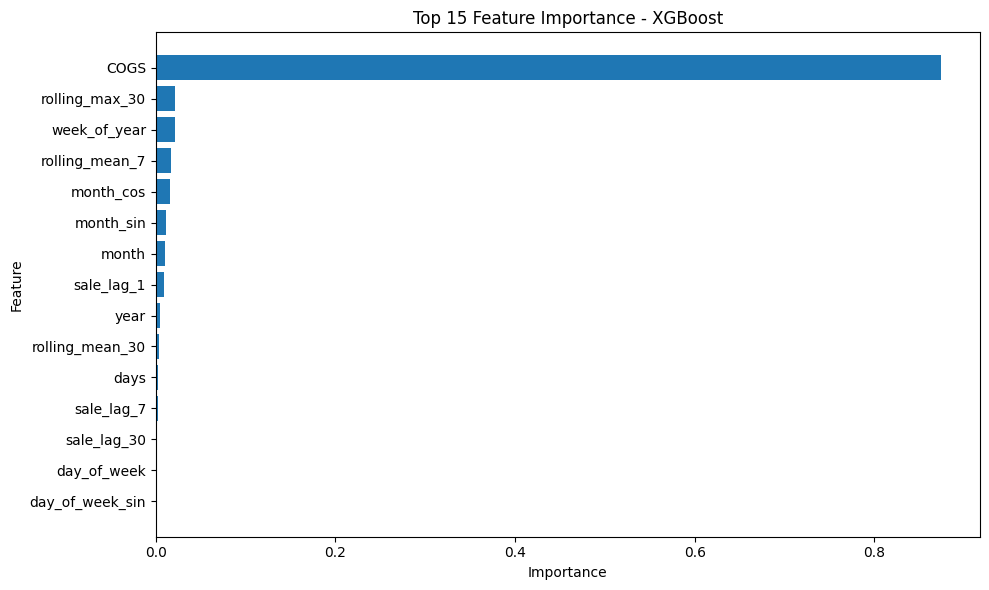

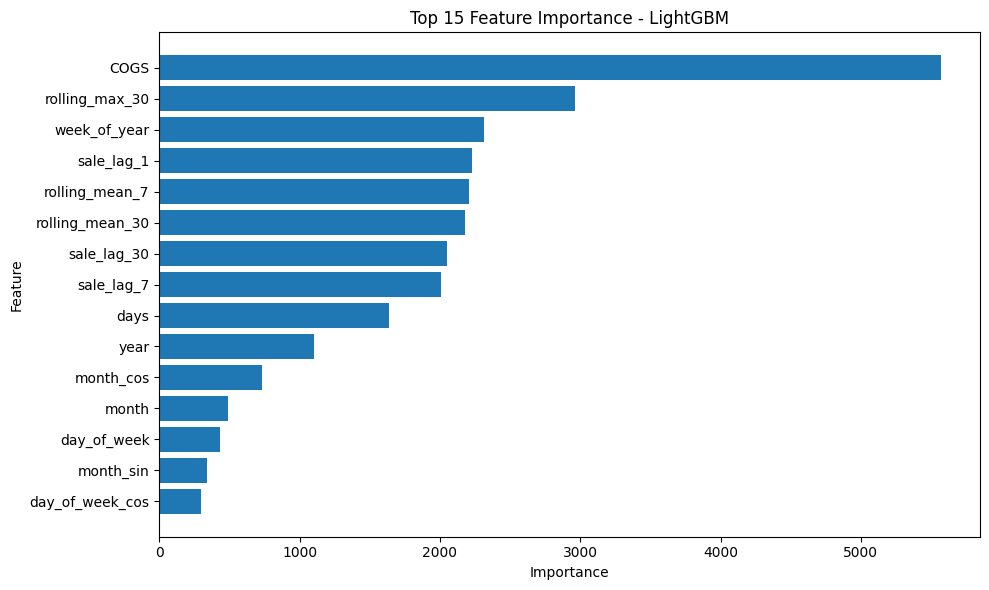

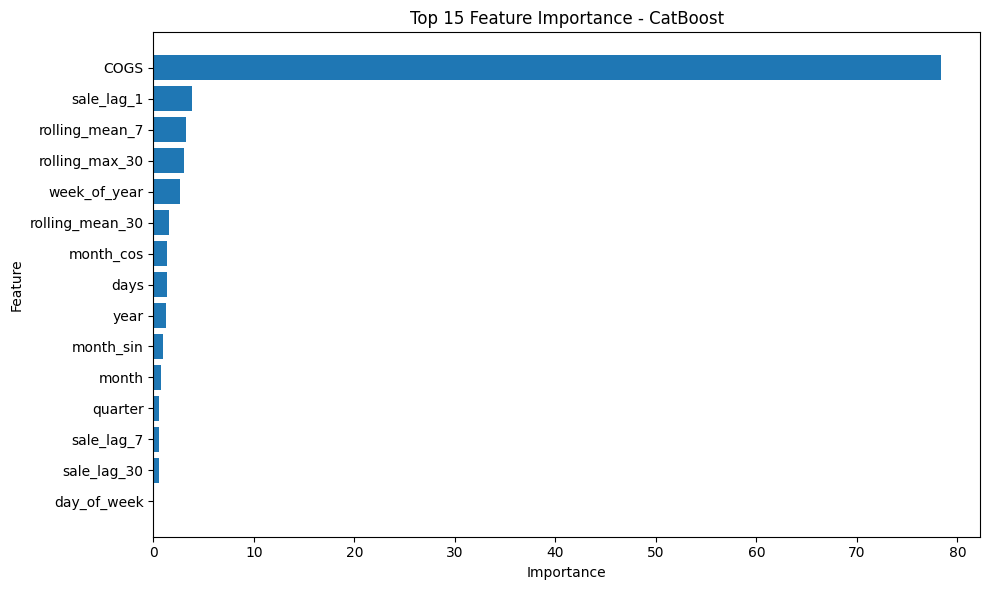

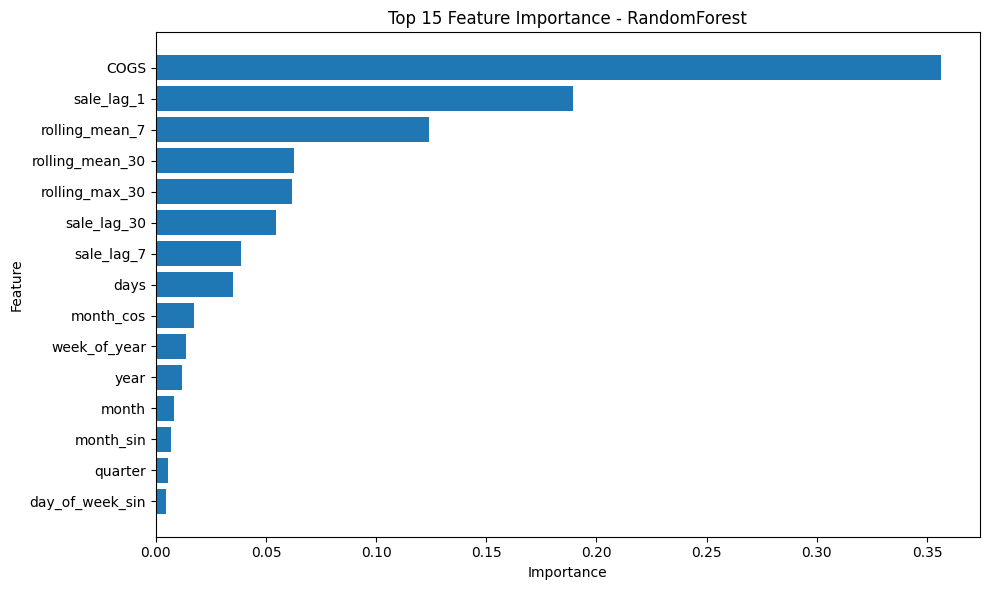

In [27]:
for name, fi in feature_importance_dict.items():
    top_fi = fi.head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(top_fi["Feature"], top_fi["Importance"])
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Feature Importance - {name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# Print best Model

In [ ]:
best_name = results_df.iloc[0]["Model"]
final_model = best_models[best_name]

print("Best model:", best_name)
print("Best params:", results_df.iloc[0]["Best Params"])

Best model: CatBoost
Best params: {'iterations': 1000, 'l2_leaf_reg': 1, 'learning_rate': 0.05}


In [ ]:
final_pred = final_model.predict(X_test)

compare_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": final_pred,
    "Error": y_test.values - final_pred
})

compare_df.head()

,Actual,Predicted,Error
0,2665507.20,2.547974e+06,117532.940042
1,1280007.89,1.314866e+06,-34857.753650
2,1015899.51,9.253559e+05,90543.595644
3,1142997.27,1.029907e+06,113090.640389
4,1236312.34,1.103973e+06,132338.870959


# Summary

- CatBoost là mô hình tốt nhất với MAE 71,392 và RMSE 99,711, cho thấy sai số dự báo trung bình ở mức thấp so với quy mô doanh thu hàng ngày.
- CatBoost cải thiện MAE khoảng 7.3% so với LightGBM, 14.1% so với XGBoost và 44.0% so với RandomForest.
- CatBoost cải thiện RMSE khoảng 10.8% so với LightGBM, 13.5% so với XGBoost và 48.7% so với RandomForest, nghĩa là kiểm soát tốt hơn các ngày có biến động lớn.
- R² của CatBoost đạt 0.9960, nghĩa là mô hình giải thích được khoảng 99.6% biến động của doanh thu trong tập đánh giá.
- RandomForest là baseline yếu nhất trong 4 mô hình, phản ánh hạn chế của bagging khi xử lý bài toán dự báo có cấu trúc thời gian và xu hướng.
